In [24]:
import numpy as np
import pandas as pd
import sqlalchemy as db
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from src.get_all_data import get_all_data
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib

In [25]:
engine = db.create_engine('sqlite:///../data/raw/data.db')
df = get_all_data(engine)

Searching for events

[+] US Federal Funds Rate
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Statement
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Press Conference
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Economic Projections
Skipped — next release on 2026-06-17 (not yet passed)

[+] US Core CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI y/y
Skipped — next release on 2026-04-10 (not yet passed)

[+] US PPI m/m
Skipped — next release on 2026-04-14 (not yet passed)

[+] US Core PCE Price Index m/m
Skipped — next release on 2026-04-09 (not yet passed)

[+] US Non-Farm Employment Change
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Unemployment Rate
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Average Hourly Earnings m/m
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Advance GD

C:\Users\usuario\Desktop\Python\Market Regime\data\interim\process_db.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['EMA_14'] = ta.EMA(close, timeperiod=14)
C:\Users\usuario\Desktop\Python\Market Regime\data\interim\process_db.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['EMA_30'] = ta.EMA(close, timeperiod=30)
C:\Users\usuario\Desktop\Python\Market Regime\data\interim\process_db.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

All done


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4778 entries, 2007-03-29 to 2026-03-30
Columns: 167 entries, spy_open to US FOMC Statement
dtypes: float64(167)
memory usage: 6.1 MB


In [27]:
df.columns.tolist()

['spy_open',
 'spy_high',
 'spy_low',
 'spy_close',
 'spy_volume',
 'spy_EMA_14',
 'spy_EMA_30',
 'spy_EMA_60',
 'spy_SMA_14',
 'spy_SMA_30',
 'spy_SMA_60',
 'spy_BB_upper',
 'spy_BB_middle',
 'spy_BB_lower',
 'spy_RSI_14',
 'spy_RSI_21',
 'spy_RSI_30',
 'spy_MACD',
 'spy_MACD_signal',
 'spy_MACD_hist',
 'spy_AROON_down',
 'spy_AROON_up',
 'spy_MFI',
 'spy_AVGPRICE',
 'spy_MEDPRICE',
 'qqq_open',
 'qqq_high',
 'qqq_low',
 'qqq_close',
 'qqq_volume',
 'qqq_EMA_14',
 'qqq_EMA_30',
 'qqq_EMA_60',
 'qqq_SMA_14',
 'qqq_SMA_30',
 'qqq_SMA_60',
 'qqq_BB_upper',
 'qqq_BB_middle',
 'qqq_BB_lower',
 'qqq_RSI_14',
 'qqq_RSI_21',
 'qqq_RSI_30',
 'qqq_MACD',
 'qqq_MACD_signal',
 'qqq_MACD_hist',
 'qqq_AROON_down',
 'qqq_AROON_up',
 'qqq_MFI',
 'qqq_AVGPRICE',
 'qqq_MEDPRICE',
 '^vix_open',
 '^vix_high',
 '^vix_low',
 '^vix_close',
 '^vix_volume',
 '^vix_EMA_14',
 '^vix_EMA_30',
 '^vix_EMA_60',
 '^vix_SMA_14',
 '^vix_SMA_30',
 '^vix_SMA_60',
 '^vix_BB_upper',
 '^vix_BB_middle',
 '^vix_BB_lower',
 '^

In [28]:
df.head()

,spy_open,spy_high,spy_low,spy_close,spy_volume,spy_EMA_14,spy_EMA_30,spy_EMA_60,spy_SMA_14,spy_SMA_30,...,CPIAUCSL,T5YIE,T10YIE,ICSA,WALCL,M2SL,TEDRATE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement
date,,,,,,,,,,,,,,,,,,,,,
2007-03-29,100.615065,100.664481,99.662143,100.212723,139432700.0,100.001746,99.905028,99.687977,99.588258,99.853327,...,205.288,2.53,2.46,303000.0,863067.0,7134.3,0.44,1490.0,1490.0,41.0
2007-03-30,100.403285,100.826802,99.217414,100.233871,128194100.0,100.032696,99.926244,99.705875,99.667267,99.777470,...,205.288,2.51,2.44,303000.0,863067.0,7134.3,0.45,1489.0,1489.0,40.0
2007-04-02,100.346802,100.558566,99.866803,100.346802,79416400.0,100.074577,99.953377,99.726889,99.891945,99.707018,...,205.288,2.50,2.44,303000.0,863067.0,7168.2,0.44,1486.0,1486.0,37.0
2007-04-03,100.918521,101.631448,100.876171,101.426750,82417800.0,100.254867,100.048433,99.782622,100.142038,99.665299,...,205.288,2.47,2.42,303000.0,863067.0,7168.2,0.44,1485.0,1485.0,36.0
2007-04-04,101.426784,101.610307,101.052673,101.539726,63995200.0,100.426181,100.144646,99.840232,100.390659,99.628752,...,205.288,2.49,2.43,303000.0,869803.0,7168.2,0.43,1484.0,1484.0,35.0


In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [30]:
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [31]:
def make_prior_from_durations(durations_days: list[float], n_states: int, alpha_off: float = 1.0) -> np.ndarray:

    prior = np.full((n_states, n_states), alpha_off)
    for i, duration in enumerate(durations_days):
        # p_ii = (D-1)/D → alpha_diag = (D-1)*(n-1)*alpha_off
        prior[i, i] = (duration - 1) * (n_states - 1) * alpha_off
    return prior
durations = [66, 51, 24, 84, 134]

n_states = 5
prior_matrix = make_prior_from_durations(durations, n_states)
print("Prior matrix:")
print(prior_matrix)

for i in range(n_states):
    p_ii = prior_matrix[i, i] / prior_matrix[i].sum()
    print(f"  State {i}: {1/(1-p_ii):.1f} days")

Prior matrix:
[[260.   1.   1.   1.   1.]
 [  1. 200.   1.   1.   1.]
 [  1.   1.  92.   1.   1.]
 [  1.   1.   1. 332.   1.]
 [  1.   1.   1.   1. 532.]]
  State 0: 66.0 days
  State 1: 51.0 days
  State 2: 24.0 days
  State 3: 84.0 days
  State 4: 134.0 days


In [32]:

prior_matrix = make_prior_from_durations(
    durations_days=durations,
    n_states=n_states,
    alpha_off=1.0
)

model = GaussianHMM(
    n_components=n_states,
    transmat_prior=prior_matrix,
    n_iter=2000,
    covariance_type="diag",
    random_state=42,

    tol=1e-4,
)
model.init_params = "stmc"
model.fit(X_pca)

print(f"Converged: {model.monitor_.converged}")
print(f"Log-likelihood: {model.score(X_pca):.2f}")

# learned durations
for i in range(n_states):
    p_ii = model.transmat_[i, i]
    print(f"  State {i}: {1/(1-p_ii+1e-9):.1f} days (p_ii={p_ii:.3f})")

Converged: True
Log-likelihood: -173026.51
  State 0: 54.4 days (p_ii=0.982)
  State 1: 16.5 days (p_ii=0.939)
  State 2: 53.6 days (p_ii=0.981)
  State 3: 290.9 days (p_ii=0.997)
  State 4: 59.8 days (p_ii=0.983)


In [33]:
#save the featured cols for
joblib.dump(list(df.columns), '../models/feature_cols.pkl')

['../models/feature_cols.pkl']

In [34]:
states = model.predict(X_pca)
df['state'] = states

In [35]:
df.head()

,spy_open,spy_high,spy_low,spy_close,spy_volume,spy_EMA_14,spy_EMA_30,spy_EMA_60,spy_SMA_14,spy_SMA_30,...,T5YIE,T10YIE,ICSA,WALCL,M2SL,TEDRATE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement,state
date,,,,,,,,,,,,,,,,,,,,,
2007-03-29,100.615065,100.664481,99.662143,100.212723,139432700.0,100.001746,99.905028,99.687977,99.588258,99.853327,...,2.53,2.46,303000.0,863067.0,7134.3,0.44,1490.0,1490.0,41.0,0
2007-03-30,100.403285,100.826802,99.217414,100.233871,128194100.0,100.032696,99.926244,99.705875,99.667267,99.777470,...,2.51,2.44,303000.0,863067.0,7134.3,0.45,1489.0,1489.0,40.0,0
2007-04-02,100.346802,100.558566,99.866803,100.346802,79416400.0,100.074577,99.953377,99.726889,99.891945,99.707018,...,2.50,2.44,303000.0,863067.0,7168.2,0.44,1486.0,1486.0,37.0,0
2007-04-03,100.918521,101.631448,100.876171,101.426750,82417800.0,100.254867,100.048433,99.782622,100.142038,99.665299,...,2.47,2.42,303000.0,863067.0,7168.2,0.44,1485.0,1485.0,36.0,0
2007-04-04,101.426784,101.610307,101.052673,101.539726,63995200.0,100.426181,100.144646,99.840232,100.390659,99.628752,...,2.49,2.43,303000.0,869803.0,7168.2,0.43,1484.0,1484.0,35.0,0


In [36]:
df.tail()

,spy_open,spy_high,spy_low,spy_close,spy_volume,spy_EMA_14,spy_EMA_30,spy_EMA_60,spy_SMA_14,spy_SMA_30,...,T5YIE,T10YIE,ICSA,WALCL,M2SL,TEDRATE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement,state
date,,,,,,,,,,,,,,,,,,,,,
2026-03-24,651.320007,657.030029,649.880005,653.179993,96457500.0,666.312021,673.843849,677.615044,667.507263,677.509056,...,2.55,2.33,205000.0,6646344.0,22667.3,0.09,85.0,36.0,36.0,2
2026-03-25,658.669983,660.890015,654.239990,656.820007,90653800.0,665.046420,672.745537,676.933239,665.757978,676.332389,...,2.51,2.31,205000.0,6655939.0,22667.3,0.09,84.0,35.0,35.0,2
2026-03-26,652.059998,654.849976,644.820007,645.090027,96353600.0,662.385567,670.961310,675.889200,663.808694,674.770056,...,2.56,2.34,210000.0,6655939.0,22667.3,0.09,83.0,34.0,34.0,2
2026-03-27,642.500000,642.659973,638.340027,640.099976,25991922.0,659.414155,668.970256,674.715782,661.082262,673.397721,...,2.56,2.31,210000.0,6655939.0,22667.3,0.09,82.0,33.0,33.0,2
2026-03-30,640.109985,640.369995,634.679993,635.849976,43309788.0,656.272264,666.833464,673.441494,658.130118,671.867721,...,2.56,2.31,210000.0,6655939.0,22667.3,0.09,79.0,30.0,30.0,2


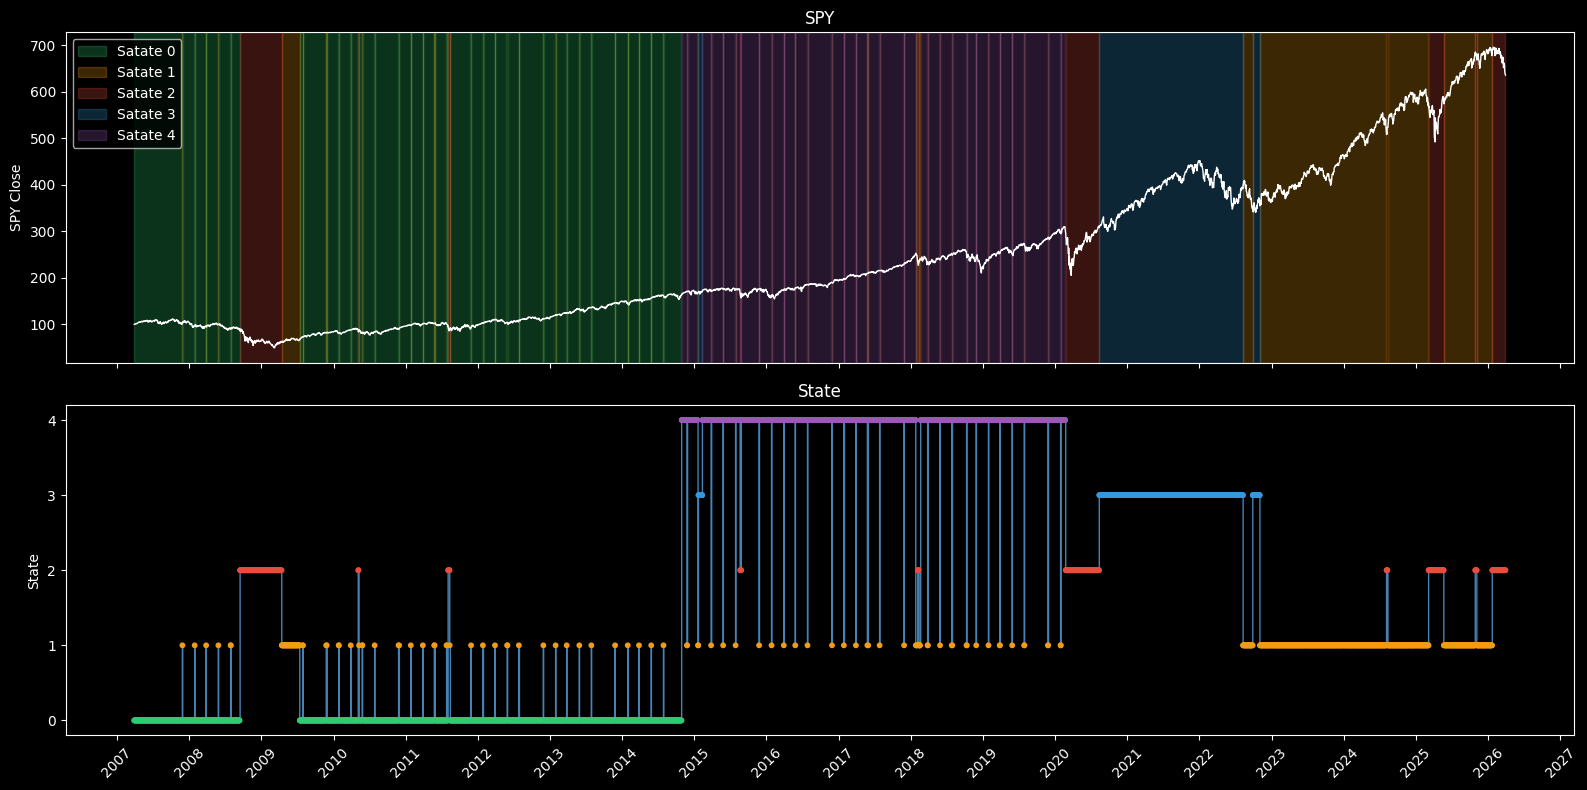

In [37]:
plt.style.use("dark_background")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

n_states = model.n_components
colors = colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db', '#9b59b6', '#e84393'][:n_states]

# ── SPY price ───────────────────────────────────────────────────────────────
ax1.plot(df.index, df['spy_close'], color='white', lw=1)
ax1.set_ylabel('SPY Close')
ax1.set_title('SPY')

for regime_id, color in enumerate(colors):
    mask = df['state'] == regime_id
    ax1.fill_between(df.index, 0, 1,
                     where=mask, alpha=0.25, color=color,
                     transform=ax1.get_xaxis_transform(),
                     label=f'Satate {regime_id}')
ax1.legend(loc='upper left')

# ── Estate ────────────────────────────────────────────────────────
ax2.plot(df.index, df['state'], color='steelblue', lw=1, drawstyle='steps-post')
ax2.scatter(df.index, df['state'],
            c=[colors[s] for s in df['state']], s=10, zorder=3)
ax2.set_yticks(range(n_states))
ax2.set_ylabel('State')
ax2.set_title('State')

ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

#save the img

plt.savefig('regimes.png', dpi=300, bbox_inches='tight')


plt.tight_layout()
plt.show()

In [38]:
#save model, scaler and pca
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(pca, '../models/pca.pkl')
joblib.dump(model, '../models/hmm_model.pkl')

['../models/hmm_model.pkl']

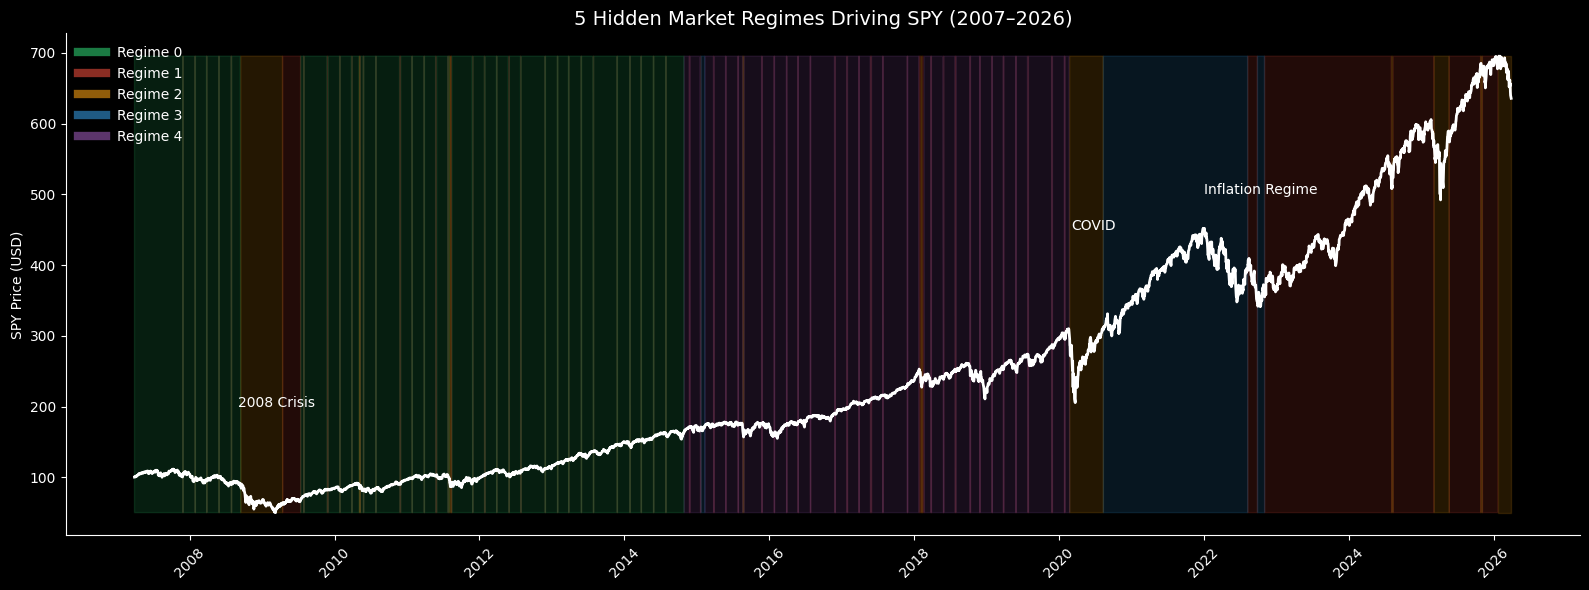

In [39]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(16, 6))

n_states = model.n_components

colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#e84393'][:n_states]

# ── SPY price ─────────────────────────────────────────────────────
ax.plot(df.index, df['spy_close'], color='white', lw=2)

ax.set_ylabel('SPY Price (USD)')
ax.set_title('5 Hidden Market Regimes Driving SPY (2007–2026)', fontsize=14)

# ── Regimes as background ─────────────────────────────────────────
for regime_id, color in enumerate(colors):
    mask = df['state'] == regime_id

    ax.fill_between(
        df.index,
        df['spy_close'].min(),
        df['spy_close'].max(),
        where=mask,
        color=color,
        alpha=0.15,
        interpolate=True
    )

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

handles = [
    plt.Line2D([0], [0], color=color, lw=6, alpha=0.6)
    for color in colors
]

labels = [f'Regime {i}' for i in range(n_states)]

ax.legend(handles, labels, loc='upper left', frameon=False)

ax.text(pd.Timestamp('2008-09-01'), 200, '2008 Crisis', color='white')
ax.text(pd.Timestamp('2020-03-01'), 450, 'COVID', color='white')
ax.text(pd.Timestamp('2022-01-01'), 500, 'Inflation Regime', color='white')

# ── Guardar ───────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('regimes_clean.png', dpi=300, bbox_inches='tight')

plt.show()